Import required libraries

In [1]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold

Data loading and standardization

In [2]:
X_raw = np.loadtxt("dataF_final.csv", delimiter=",")
Y_raw = np.loadtxt("dataC_final.csv", delimiter=",")
if Y_raw.ndim == 1: Y_raw = Y_raw.reshape(-1, 1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X = scaler_x.fit_transform(X_raw)
Y = scaler_y.fit_transform(Y_raw)

Cross-validated RMSE for subset evaluation

In [3]:
def cv_rmse(X, y, n_components=20):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    comp = min(n_components, X.shape[1])
    model = PLSRegression(n_components=comp)
    for tr, te in kf.split(X):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))
    return np.mean(rmses)

Variable Importance in Projection (VIP)

VIP scores measure the contribution of each wavelength to the PLS model.

In [4]:
def compute_vip(pls, X):
    t, w, q = pls.x_scores_, pls.x_weights_, pls.y_loadings_
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    Wnorm2 = np.sum(w ** 2, axis=0)
    vip = np.zeros(p)
    for i in range(p):
        weight = np.sum([s[j] * (w[i,j]**2) / Wnorm2[j] for j in range(h)])
        vip[i] = np.sqrt(p * weight / np.sum(s))
    return vip


Sparse Competitive Adaptive Reweighted Sampling

In [ ]:
def sparse_cars(X, y_single, n_iter=80):
    idx = np.arange(X.shape[1])
    best_subset = idx.copy()
    min_rmse = float('inf')
    
    for i in range(n_iter):
        Xs = X[:, idx]
        # Evaluate fitness
        pls = PLSRegression(n_components=min(20, Xs.shape[1]))
        pls.fit(Xs, y_single)

        vip = compute_vip(pls, Xs)
        lasso = Lasso(alpha=0.001, max_iter=10000).fit(Xs, y_single)
        beta = np.abs(lasso.coef_)
        importance = vip * beta + 1e-12
        
        
        current_rmse = cv_rmse(Xs, y_single)
        if current_rmse < min_rmse:
            min_rmse = current_rmse
            best_subset = idx.copy()
        
        # Eliminate bottom 10% of features
        if len(idx) <= 5: break
        new_size = max(5, int(len(idx) * 0.9))
        idx = idx[np.argsort(-importance)[:new_size]]
        
    return best_subset


Regression models and cross-validation

In [6]:
results_list_sparse = []
all_predictions_sparse = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

test_models = {
    "PLSR": PLSRegression(n_components=20),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.001)
}

Sparse CARS and Model evaluation

In [ ]:
print(f"{'Target':<8} | {'Model':<12} | {'R2_test':<10} | {'RMSE_test':<10} | {'Features':<8}")
print("-" * 70)

for t in range(Y.shape[1]):
    print(f"\nOptimizing Target {t+1}...")
    start = time.time()

    y_target = Y[:, t]
    best_idx = sparse_cars(X, y_target)
    X_selected = X[:, best_idx]

    fold_scores = {name: {"r2": [], "rmse": []} for name in test_models.keys()}
    temp_true = {name: [] for name in test_models.keys()}
    temp_pred = {name: [] for name in test_models.keys()}

    for train_idx, test_idx in kf.split(X_selected):

        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_target[train_idx], y_target[test_idx]

        for name, model in test_models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test).flatten()

            temp_true[name].extend(y_test)
            temp_pred[name].extend(pred)

            r2 = r2_score(y_test, pred)
            rmse = np.sqrt(mean_squared_error(y_test, pred))

            fold_scores[name]["r2"].append(r2)
            fold_scores[name]["rmse"].append(rmse)

    for name in test_models.keys():
        mean_r2 = np.mean(fold_scores[name]["r2"])
        mean_rmse = np.mean(fold_scores[name]["rmse"])

        results_list_sparse.append({
            "Target": t+1,
            "Model": name,
            "R2_test": mean_r2,
            "RMSE_test": mean_rmse,
            "Features": len(best_idx)  
        })

        all_predictions_sparse[(t+1, name)] = (
            np.array(temp_true[name]),
            np.array(temp_pred[name])
        )

        print(f"T{t+1:<6} | {name:<12} | {mean_r2:.4f}   | {mean_rmse:.4f}   | {len(best_idx):<8}")

    print(f"RunTime: {time.time() - start:.2f}s")

Target   | Model        | R2_test    | RMSE_test  | Features
----------------------------------------------------------------------

Optimizing Target 1...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.717e-02, tolerance: 2.580e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.190e-02, tolerance: 2.580e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.543e-02, tolerance: 2.5

T1      | PLSR         | 0.9505   | 0.2189   | 162     
T1      | Ridge        | 0.9663   | 0.1806   | 162     
T1      | Lasso        | 0.9400   | 0.2406   | 162     
T1      | ElasticNet   | 0.9668   | 0.1796   | 162     
RunTime: 39.02s

Optimizing Target 2...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.250e-02, tolerance: 2.065e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.723e-01, tolerance: 2.065e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.525e-02, tolerance: 2.0

T2      | PLSR         | 0.9497   | 0.2217   | 180     
T2      | Ridge        | 0.9643   | 0.1876   | 180     
T2      | Lasso        | 0.9303   | 0.2601   | 180     
T2      | ElasticNet   | 0.9633   | 0.1908   | 180     
RunTime: 18.29s

Optimizing Target 3...


...

c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.085e-01, tolerance: 1.964e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.865e-01, tolerance: 1.964e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.423e-02, tolerance: 1.8

T4      | PLSR         | 0.9516   | 0.2139   | 200     
T4      | Ridge        | 0.9658   | 0.1779   | 200     
T4      | Lasso        | 0.9017   | 0.3080   | 200     
T4      | ElasticNet   | 0.9705   | 0.1671   | 200     
RunTime: 26.12s

Optimizing Target 5...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.581e-02, tolerance: 2.580e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.712e-02, tolerance: 2.580e-02
  model = cd_fast.enet_coordinate_descent(


T5      | PLSR         | 0.8760   | 0.2816   | 145     
T5      | Ridge        | 0.8846   | 0.2739   | 145     
T5      | Lasso        | 0.8602   | 0.3039   | 145     
T5      | ElasticNet   | 0.8790   | 0.2790   | 145     
RunTime: 34.85s


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.216e-01, tolerance: 1.324e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.098e-01, tolerance: 2.350e-02
  model = cd_fast.enet_coordinate_descent(


Best Model Per Target (Sparse CARS)

In [11]:
results_df_sparse = pd.DataFrame(results_list_sparse)
best_models_sparse = (
    results_df_sparse.sort_values("RMSE_test")
    .groupby("Target")
    .first()
    .reset_index()
)

best_models_sparse

,Target,Model,R2_test,RMSE_test,Features
0,1,ElasticNet,0.966770,0.179560,162
1,2,Ridge,0.964279,0.187624,180
2,3,Ridge,0.958312,0.181892,162
3,4,ElasticNet,0.970523,0.167092,200
4,5,Ridge,0.884631,0.273884,145


Predicted vs Observed for best model per target

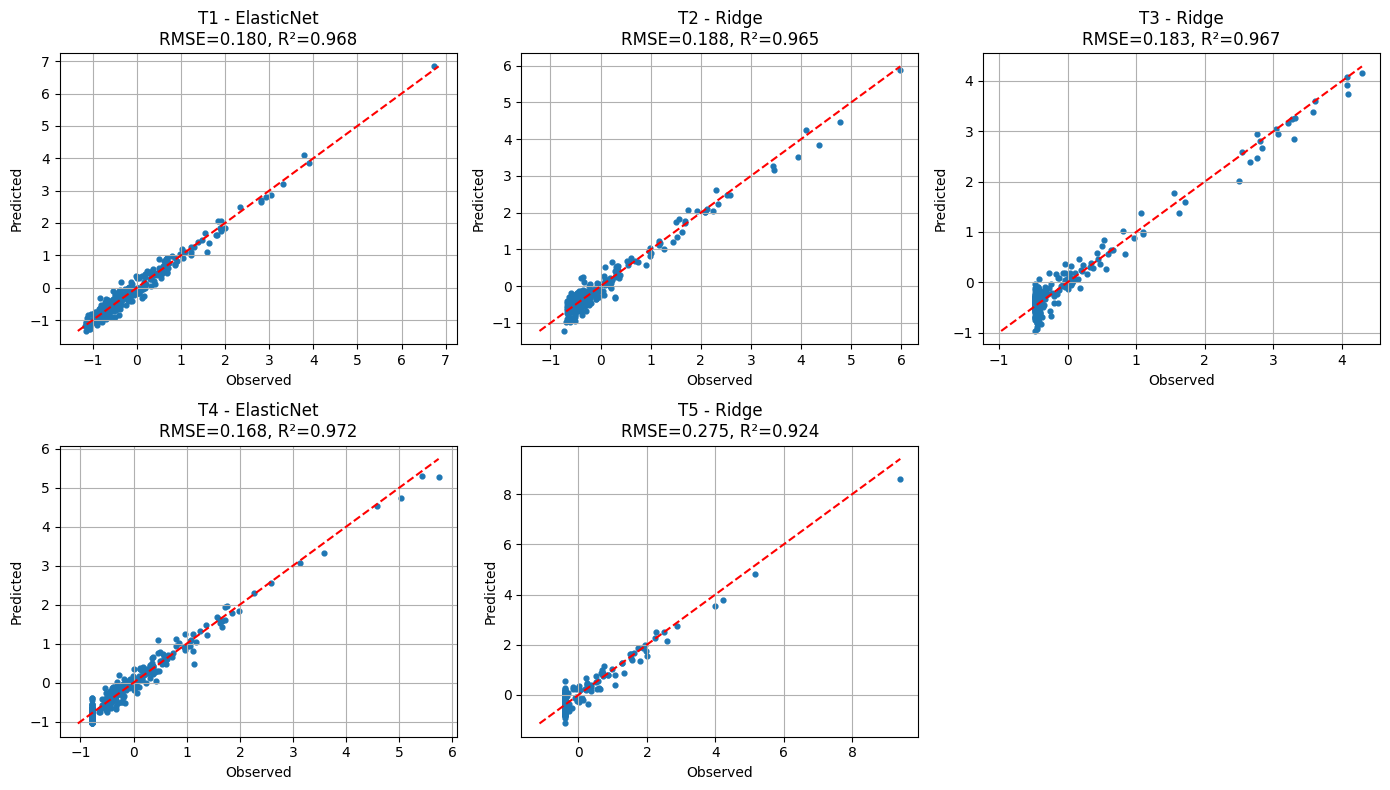

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def plot_best_models(best_models, all_predictions):
    
    cols = 3
    rows = int(np.ceil(len(best_models) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for i, row in best_models.iterrows():
        t = row["Target"]
        model = row["Model"]

        y_true, y_pred = all_predictions[(t, model)]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        plt.subplot(rows, cols, i + 1)
        plt.scatter(y_true, y_pred, s=12)

        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        plt.plot([min_v, max_v], [min_v, max_v], "r--")

        plt.title(f"T{t} - {model}\nRMSE={rmse:.3f}, R²={r2:.3f}")
        plt.xlabel("Observed")
        plt.ylabel("Predicted")
        plt.grid()

    plt.tight_layout()
    plt.show()
    
plot_best_models(best_models_sparse, all_predictions_sparse)